<a href="https://colab.research.google.com/github/DaniGa-Mo/VISUALIZACI-N-Y-AN-LISIS-DE-DATOS-ESTRAT-GICOS-CON-PYTHON/blob/main/Entrega_2_Daniel_Gallardo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

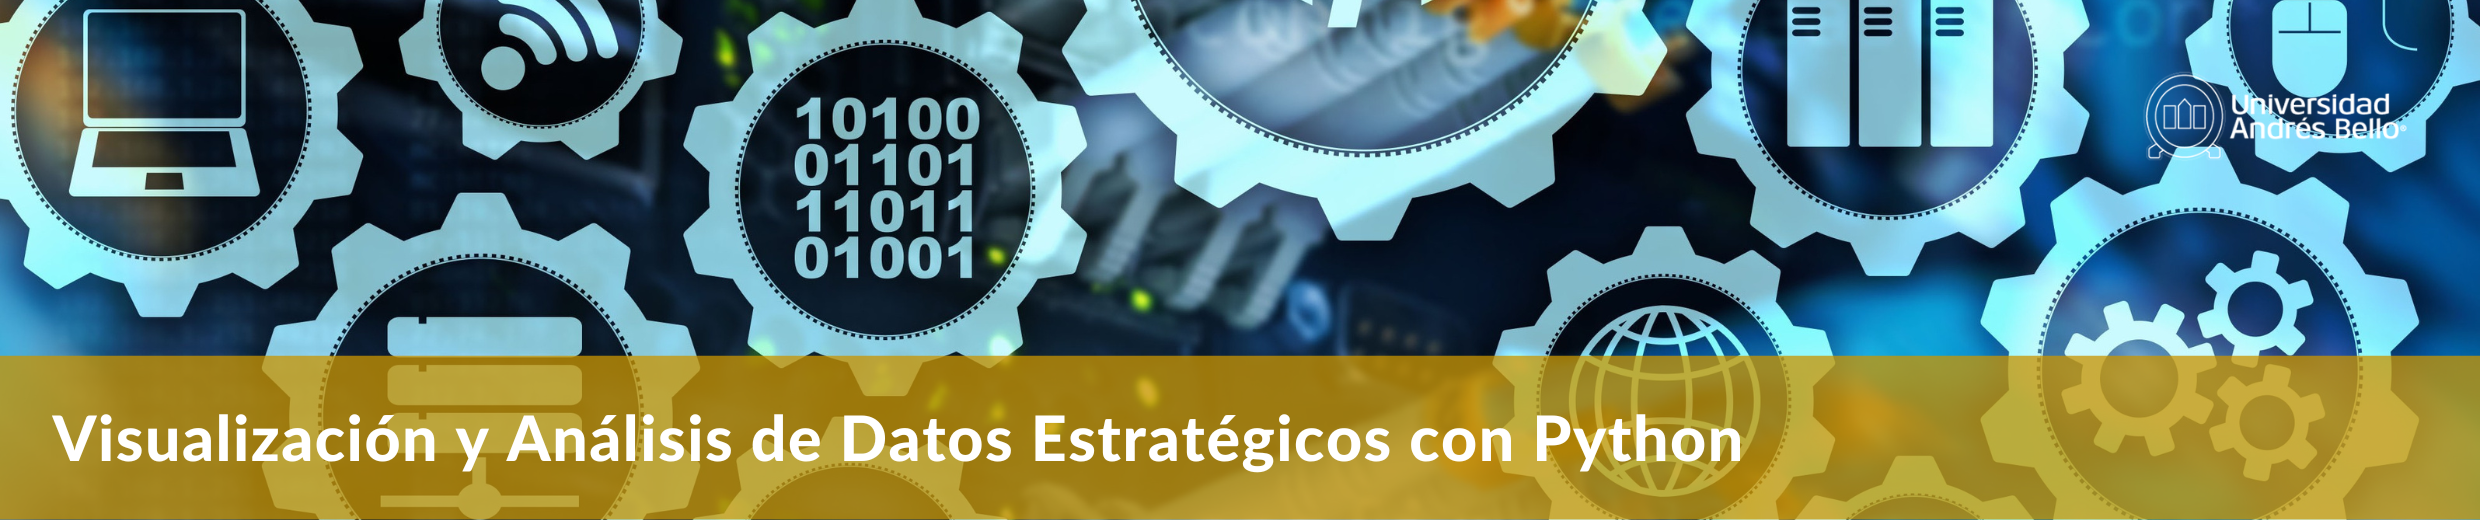

# Informe de Proyecto: Análisis Estratégico de Ventas Retail
---
**Estudiante:** Daniel Gallardo Monsalves

**Universidad:** Universidad Andrés Bello  
**Postgrado:** Diplomado Python para la Toma de Decisiones  Estratégicas Organizacionales  
**Código asignatura:** ECEN553  
**Docente:** Jorge Márquez  

---

# **Entrega 1**

*"Definición del Proyecto y Análisis Conceptual"*

## 1. Definición del Problema y Preguntas de Análisis

### 1.1 Contexto del Problema

Una cadena de supermercados con presencia en distintas ciudades de Myanmar busca optimizar sus estrategias de inventario y marketing. A pesar de tener ventas estables, la gerencia no tiene claridad sobre qué líneas de productos son más rentables según el tipo de cliente y cómo fluctúan las ventas durante las distintas horas del día y días de la semana. Este análisis visual permitirá identificar patrones de consumo para ajustar horarios de personal y promociones dirigidas.

### 1.2 Pregunta Principal

¿Cuáles son los patrones de consumo y rentabilidad por línea de producto que deben guiar la estrategia de ventas y asignación de recursos de la cadena de supermercados?

### 1.3 Preguntas Secundarias

- ¿Cómo varía el volumen de ventas y la satisfacción del cliente a lo largo de las diferentes horas del día?.

- ¿Qué líneas de productos generan el mayor margen de beneficio bruto según el género y tipo de cliente?.

- ¿Existe una correlación entre el precio unitario de los productos y la calificación dada por los clientes?.

## 2. Descripción del Conjunto de Datos (Dataset)

### 2.1 Fuente y Estructura

- **Fuente:** El conjunto de datos ha sido obtenido de la plataforma Kaggle, bajo el título "Supermarket Sales Dataset". Este dataset contiene registros históricos de transacciones de una empresa del sector retail recopilados durante un periodo de tres meses.

- [Link del Dataset](https://www.kaggle.com/datasets/faresashraf1001/supermarket-sales)

- El dataset a sido descargado y subido a un repositorio en github donde se realiza la extracción para el posterior analisis.


In [15]:
url = 'https://raw.githubusercontent.com/DaniGa-Mo/VISUALIZACI-N-Y-AN-LISIS-DE-DATOS-ESTRAT-GICOS-CON-PYTHON/refs/heads/main/SuperMarket_Analysis.csv'

- **Estructura**

In [16]:
# Importación de librerias
import pandas as pd
import matplotlib.pyplot as plt


In [17]:
# Lectura archivo csv y composición
df = pd.read_csv(url)
df.shape

(1000, 17)

- El archivo está compuesto por una matriz de 1,000 registros (filas) y 17 variables (columnas).

### Diccionario de Datos

In [18]:
# 1. Diccionario de Datos
data_dict = {
    "Nombre de la Columna": [
        "Invoice ID", "Branch", "City", "Customer type", "Gender",
        "Product line", "Unit price", "Quantity", "Tax 5%", "Sales",
        "Date", "Time", "Payment", "COGS", "Gross margin percentage",
        "Gross income", "Rating"
    ],
    "Descripción": [
        "Identificador único de la factura", "Letra de la sucursal", "Ciudad de ubicación",
        "Tipo de membresía del cliente", "Género del cliente", "Categoría del producto",
        "Precio unitario en USD", "Cantidad de unidades compradas", "Impuesto del 5%",
        "Costo total con impuesto", "Fecha de la transacción", "Hora de la compra",
        "Método de pago", "Costo de bienes vendidos", "Porcentaje de margen bruto",
        "Ganancia bruta", "Calificación de satisfacción"
    ],
    "Tipo de Variable": [
        "Categórica Nominal", "Categórica Nominal", "Categórica Nominal",
        "Categórica Dicotómica", "Categórica Dicotómica", "Categórica Nominal",
        "Cuantitativa de Proporción", "Cuantitativa de Intervalo", "Cuantitativa de Proporción",
        "Cuantitativa de Proporción", "Especial Temporal", "Especial Temporal",
        "Categórica Nominal", "Cuantitativa de Proporción", "Cuantitativa de Proporción",
        "Cuantitativa de Proporción", "Categórica Ordinal"
    ],
    "Valores Posibles (si aplica)": [
        "N/A", "A, B, C", "Yangon, Naypyitaw, Mandalay",
        "Member, Normal", "Female, Male", "Health & Beauty, Electronic accessories, etc.",
        "N/A", "1 a 10", "N/A", "N/A", "Enero - Marzo 2019", "10:00 - 20:59",
        "Ewallet, Cash, Credit card", "N/A", "4.76190476%", "N/A", "Escala 1 a 10"
    ]
}

diccionario_df = pd.DataFrame(data_dict)

# 2. Aplicar estilo para alinear a la izquierda
# 'props' define la propiedad CSS 'text-align' como 'left'
styled_df = diccionario_df.style.set_properties(**{'text-align': 'left'}).set_table_styles([
    dict(selector='th', props=[('text-align', 'left')]) # Esto alinea también los encabezados
])

# 3. Mostrar la tabla
display(styled_df)

,Nombre de la Columna,Descripción,Tipo de Variable,Valores Posibles (si aplica)
0,Invoice ID,Identificador único de la factura,Categórica Nominal,N/A
1,Branch,Letra de la sucursal,Categórica Nominal,"A, B, C"
2,City,Ciudad de ubicación,Categórica Nominal,"Yangon, Naypyitaw, Mandalay"
3,Customer type,Tipo de membresía del cliente,Categórica Dicotómica,"Member, Normal"
4,Gender,Género del cliente,Categórica Dicotómica,"Female, Male"
5,Product line,Categoría del producto,Categórica Nominal,"Health & Beauty, Electronic accessories, etc."
6,Unit price,Precio unitario en USD,Cuantitativa de Proporción,N/A
7,Quantity,Cantidad de unidades compradas,Cuantitativa de Intervalo,1 a 10
8,Tax 5%,Impuesto del 5%,Cuantitativa de Proporción,N/A
9,Sales,Costo total con impuesto,Cuantitativa de Proporción,N/A


# Entrega 2

Pregunta Principal de Negocio:
¿Cuáles son los patrones de consumo y rentabilidad por línea de producto que deben guiar la estrategia de ventas y asignación de recursos de la cadena de supermercados?

## 1. Diagnóstico Inicial del Dataset

En esta sección, preparamos el entorno de trabajo y realizamos una primera inspección para entender la "forma" de nuestros datos de ventas de supermercado.

Para iniciar el proceso de análisis, importamos la librería Pandas y cargamos el dataset, paso que se realizo en la entrega_1. El primer paso crítico es realizar un diagnóstico técnico para conocer la cantidad de registros, los tipos de datos asignados automáticamente y detectar la presencia de valores nulos que puedan afectar la integridad de los resultados estadísticos posteriores.

In [19]:
# Visualización de las dimensiones (Filas, Columnas)
print(f"El dataset cuenta con {df.shape[0]} filas y {df.shape[1]} columnas.")

El dataset cuenta con 1000 filas y 17 columnas.


In [20]:
# .columns | nombre de las columnas del dataset
df.columns

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Sales', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating'],
      dtype='object')

In [21]:
# Diagnóstico de tipos de datos y nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

In [22]:
df.describe()

,Unit price,Quantity,Tax 5%,Sales,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1.000000e+03,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905e+00,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,6.131498e-14,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905e+00,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905e+00,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905e+00,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905e+00,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905e+00,49.650000,10.00000


In [23]:
# Visualización de las primeras 5 filas para inspección visual
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [24]:
# Visualización de las últimas 5 filas para inspección visual
df.tail()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
995,233-67-5758,Giza,Naypyitaw,Normal,Male,Health and beauty,40.35,1,2.0175,42.3675,1/29/2019,1:46:00 PM,Ewallet,40.35,4.761905,2.0175,6.2
996,303-96-2227,Cairo,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.6900,1022.4900,3/2/2019,5:16:00 PM,Ewallet,973.80,4.761905,48.6900,4.4
997,727-02-1313,Alex,Yangon,Member,Male,Food and beverages,31.84,1,1.5920,33.4320,2/9/2019,1:22:00 PM,Cash,31.84,4.761905,1.5920,7.7
998,347-56-2442,Alex,Yangon,Normal,Male,Home and lifestyle,65.82,1,3.2910,69.1110,2/22/2019,3:33:00 PM,Cash,65.82,4.761905,3.2910,4.1
999,849-09-3807,Alex,Yangon,Member,Female,Fashion accessories,88.34,7,30.9190,649.2990,2/18/2019,1:28:00 PM,Cash,618.38,4.761905,30.9190,6.6


## 2. Limpieza y Transformación de Datos

Antes de proceder con el análisis profundo, es imperativo asegurar la calidad de los datos. Un dataset de retail como el de SuperMarket Analysis puede contener inconsistencias en los nombres de las columnas o tipos de datos mal asignados que impedirían cálculos matemáticos exactos. En esta sección, estandarizamos la estructura para asegurar la reproducibilidad del análisis.

Aplicamos el proceso de Data Quality. Primero, estandarizamos los nombres de las columnas a snake_case y renombramos 'sales' a 'total' para mayor claridad. También realizamos el casting de la columna 'date' y tratamos nulos y duplicados para asegurar que cada registro sea una transacción única y válida.

### 2.1 Estandarización y Corrección de Tipos (Casting)

In [25]:
# Estandarización de Columnas a snake_case
# Eliminamos espacios y convertimos a minúsculas para facilitar el llamado de variables en Python.
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('%', 'pct')

In [26]:
# Cambio específico de nombre (de 'sales' a 'total')
df = df.rename(columns={'sales': 'total'})

In [27]:
# Corrección de Tipos de Datos (Casting)
# Convertimos la fecha al formato datetime para análisis temporal
df['date'] = pd.to_datetime(df['date'])

In [28]:
# Aseguramos que las métricas críticas sean numéricas (uso de errors='coerce' por seguridad)
cols_numericas = ['unit_price', 'quantity', 'tax_5pct', 'total', 'cogs', 'gross_income', 'rating']
for col in cols_numericas:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Columnas estandarizadas:", df.columns.tolist())

Columnas estandarizadas: ['invoice_id', 'branch', 'city', 'customer_type', 'gender', 'product_line', 'unit_price', 'quantity', 'tax_5pct', 'total', 'date', 'time', 'payment', 'cogs', 'gross_margin_percentage', 'gross_income', 'rating']


### 2.2 Manejo de Nulos, Duplicados e Ingeniería de Características

In [29]:
# Manejo de Nulos y Duplicados
# Identificamos y eliminamos registros duplicados basados en el ID de factura
df = df.drop_duplicates(subset=['invoice_id'])

In [30]:
# Tratamiento de nulos: En este dataset, si faltan precios, usamos la mediana para no sesgar por valores extremos
df['unit_price'] = df['unit_price'].fillna(df['unit_price'].median())

In [36]:
# Cálculo del total neto (Rentabilidad sin impuestos)
df['total_neto'] = df['total'] - df['tax_5pct']

# Clasificación de 'Hora Pico' (Ventas después de las 15:00)
# Usamos el formato '%I:%M:%S %p' para evitar el UserWarning de formato ambiguo
df['hora_pico'] = pd.to_datetime(df['time'], format='%I:%M:%S %p').dt.hour >= 15

# Identificación de Fin de Semana (Patrón de consumo estacional)
# .dt.dayofweek devuelve 5 (Sábado) y 6 (Domingo)
df['es_fin_de_semana'] = df['date'].dt.dayofweek.isin([5, 6])

# Verificación de resultados
print(f"Dataset procesado con éxito: {df.shape[0]} registros.")
display(df[['time', 'hora_pico', 'date', 'es_fin_de_semana', 'total_neto']].head())

Dataset procesado con éxito: 1000 registros.


,time,hora_pico,date,es_fin_de_semana,total_neto
0,1:08:00 PM,False,2019-01-05,True,522.83
1,10:29:00 AM,False,2019-03-08,False,76.40
2,1:23:00 PM,False,2019-03-03,True,324.31
3,8:33:00 PM,True,2019-01-27,True,465.76
4,10:37:00 AM,False,2019-02-08,False,604.17


En esta sección de Ingeniería de Características, transformamos los datos brutos en indicadores estratégicos para responder a nuestra pregunta principal.

- total_neto: Representa la rentabilidad real de la venta al descontar los impuestos.

- hora_pico: Clasifica las transacciones realizadas después de las 15:00 hrs, permitiendo identificar si el volumen de compra aumenta en la jornada de tarde.

- es_fin_de_semana: Identifica si el patrón de consumo varía significativamente los días sábados y domingos.

## 3. Selección, Filtrado y Agregación (Análisis de Negocio)

En esta etapa interrogamos los datos para responder a nuestra pregunta principal. Nos interesa identificar comportamientos de compra de alto valor y entender cómo se distribuyen las ventas entre las diferentes sucursales para optimizar la logística y el stock.

Para responder a la pregunta de rentabilidad, filtramos las transacciones de alto valor (mayores al promedio) y agrupamos por línea de producto. Esto nos permite identificar qué categorías no solo venden más en volumen, sino cuáles dejan un mayor margen neto.

### 3.1 Indexación, Filtros Complejos y Ordenación

In [32]:
# Filtro Booleano Complejo
# Filtramos ventas de 'Ticket Alto': Miembros (Member) que compraron más de 500 USD en la ciudad de Yangon
filtro_estratego = (df['customer_type'] == 'Member') & (df['total'] > 500) & (df['city'] == 'Yangon')
df_alto_valor = df[filtro_estratego]

In [33]:
# Ordenación (Top 10 ventas de mayor impacto)
top_ventas = df_alto_valor.sort_values(by='total', ascending=False).head(10)
print("Top 10 ventas estratégicas en Yangon:")
display(top_ventas[['invoice_id', 'product_line', 'total']])

Top 10 ventas estratégicas en Yangon:


,invoice_id,product_line,total
429,325-77-6186,Home and lifestyle,951.8250
959,384-59-6655,Food and beverages,932.3370
105,704-48-3927,Electronic accessories,931.0350
982,139-32-4183,Sports and travel,921.1860
442,138-17-5109,Home and lifestyle,843.0345
120,638-60-7125,Electronic accessories,836.3040
68,232-11-3025,Sports and travel,827.0850
889,880-46-5796,Sports and travel,807.6600
829,416-17-9926,Electronic accessories,779.3100
887,884-80-6021,Electronic accessories,771.4350


### 3.2 Agregación (Dividir-Aplicar-Combinar)

In [34]:
# Agregación con GroupBy
# Respondemos: ¿Cuál es el ingreso neto y el rating promedio por línea de producto?
analisis_productos = df.groupby('product_line').agg({
    'total_neto': 'sum',
    'rating': 'mean',
    'quantity': 'count'
}).sort_values(by='total_neto', ascending=False)

display(analisis_productos)

,total_neto,rating,quantity
product_line,,,
Food and beverages,53471.28,7.113218,174
Sports and travel,52497.93,6.916265,166
Electronic accessories,51750.03,6.924706,170
Fashion accessories,51719.90,7.029213,178
Home and lifestyle,51297.06,6.837500,160
Health and beauty,46851.18,7.003289,152


## 4. Visualización Rápida con Pandas

Para visualizar el rendimiento, generamos un gráfico de barras que compara el ingreso neto total por línea de producto. Esto nos permite identificar visualmente qué categorías son las 'estrellas' del supermercado.

### 4.1 Gráfico Estadístico

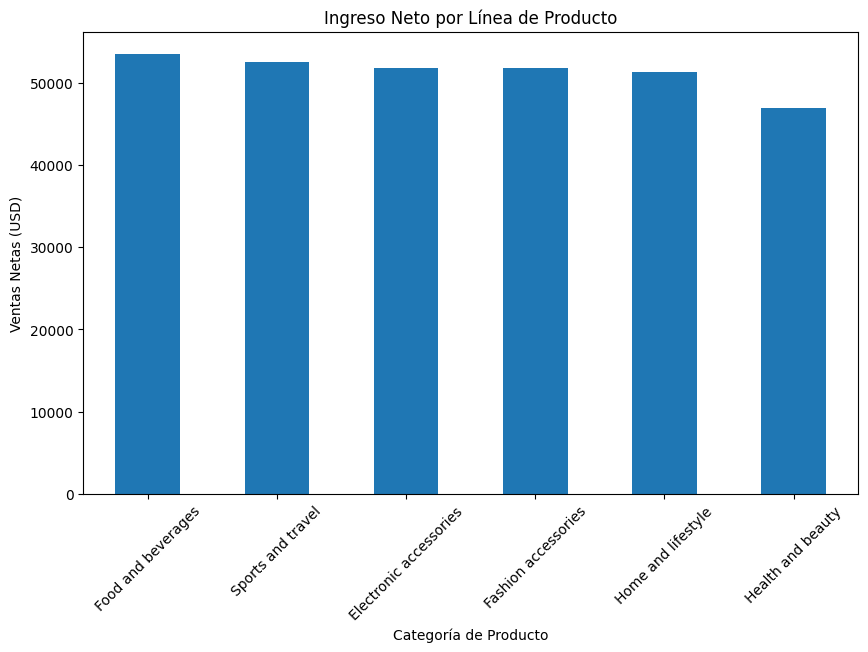

In [35]:
# Graficamos el ingreso neto por categoría
plt.figure(figsize=(10,6))
analisis_productos['total_neto'].plot(kind='bar', title='Ingreso Neto por Línea de Producto')
plt.ylabel('Ventas Netas (USD)')
plt.xlabel('Categoría de Producto')
plt.xticks(rotation=45)
plt.show()

### 4.2 Conclusión

Tras completar el proceso de limpieza y análisis exploratorio, el gráfico de rentabilidad total revela patrones de consumo críticos para la gestión de la cadena. Se observa que la línea de 'Food and beverages' (Alimentos y Bebidas) no solo lidera en volumen de ventas, sino que también representa la mayor fuente de ingresos netos para la organización.